# Figure 4 Distance-dependence and sampling scale affect network complexity measurements.

#### (A) Connection probability along distance for the ATCs (top) and the CPCs (bottom) of human (teal), rat (purple) and the HC RD (black). 

In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd 
import ast

In [4]:
path_csv_file = "/Users/natali_obi_account/Desktop/OBI/HUMAN_CORTEX/PAPERS_ON_GOING/CONNECTIVITY_PAPER/code/Human_connectivity_paper/connectivity_matrix_analysis/Fig4/connection_probability_results.csv"

In [5]:
# Check what is inside the csv file
data = pd.read_csv(path_csv_file)
data.head()

,ATC_human,CPC_human,E_to_T_human,T_to_T_human,E_to_E_human,T_to_E_human,ATC_rat,CPC_rat,E_to_T_rat,T_to_T_rat,E_to_E_rat,T_to_E_rat,HC_RD,E_to_T_HC_RD,T_to_T_HC_RD,E_to_E_HC_RD,T_to_E_HC_RD
0,"{'p_conn_dist': array([7.33860106e-01, 6.00110...","{'p_conn_dist': array([2.25489192e-01, 1.19884...","{'p_conn_dist': array([1.23628847e-01, 1.00762...","{'p_conn_dist': array([4.16285880e-01, 2.76468...","{'p_conn_dist': array([7.20338079e-02, 5.87275...","{'p_conn_dist': array([1.62071624e-01, 9.34934...","{'p_conn_dist': array([8.37547383e-01, 6.85219...","{'p_conn_dist': array([9.46677283e-02, 5.53315...","{'p_conn_dist': array([5.25254519e-02, 4.30058...","{'p_conn_dist': array([2.07068321e-01, 1.30611...","{'p_conn_dist': array([3.90442192e-02, 3.19317...","{'p_conn_dist': array([7.63938748e-02, 4.66151...","{'p_conn_dist': array([0.82651046, 0.64856319,...","{'p_conn_dist': array([0.03747854, 0.02963014,...","{'p_conn_dist': array([0.15147003, 0.10812095,...","{'p_conn_dist': array([0.03540999, 0.0277971 ,...","{'p_conn_dist': array([0.05211058, 0.03687913,..."
1,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...


In [6]:
def fill_in_func(scale_value, exponent_value, x_vector):
    y = []
    ## INPUT
    # circuit_name: str, name of the conn_mat in the csv file
    # mat_name: str, from data_frame['circuit_name']
    # scale_value: float, from data_frame['exp_model_scale']
    # exponent_value: float, from data_frame['exp_model_exponent']
    # x_vector: list, with x values 
    ## OUTPUT
    # y: list, with values to be plotted against x
    
    for x_i in x_vector:
        y_i = scale_value*np.exp((-1)*exponent_value*x_i)
        y.append(y_i)   
    return y

In [8]:
model_dict = ast.literal_eval(data['ATC_human'][1])
model_dict

scale = model_dict['model_params']['exp_model_scale']
exp = model_dict['model_params']['exp_model_exponent']

In [9]:
x_vector = list(np.arange(0, 1400, 20.))

circuit_name_list = data.head(0).keys().tolist()

results = {}

for cn in circuit_name_list:
    model_dict = ast.literal_eval(data[cn][1])
    scale = model_dict['model_params']['exp_model_scale']
    exponent = model_dict['model_params']['exp_model_exponent']
    y = fill_in_func(scale, exponent, x_vector)
    results[cn] = y

### Connection probability vs distance: ATC

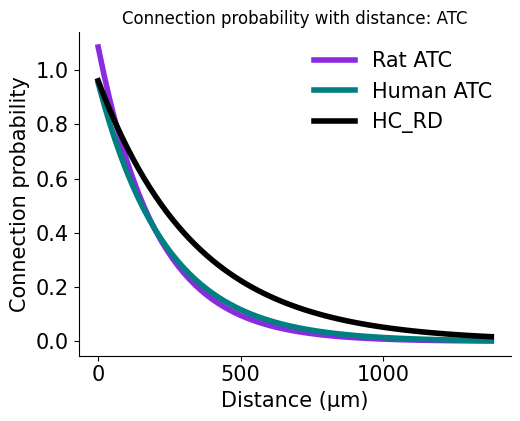

In [11]:
fig = plt.figure(figsize=(5.58, 4.2))
ax0 = plt.subplot()

ax0.plot(x_vector, results["ATC_rat"], color ='blueviolet', linestyle ='solid', linewidth = 4, label='Rat ATC')
ax0.plot(x_vector, results["ATC_human"], color = 'teal', linestyle ='solid', linewidth = 4, label= 'Human ATC')
ax0.plot(x_vector, results["HC_RD"], color = 'black', linestyle ='solid', linewidth = 4, label= 'HC_RD')

ax0.tick_params(axis='x', labelsize=15)
ax0.tick_params(axis='y', labelsize=15)
ax0.title.set_text('Connection probability with distance: ATC')
ax0.set_ylabel('Connection probability', fontsize=15)
ax0.set_xlabel('Distance (µm)', fontsize=15)
ax0.spines[['right', 'top']].set_visible(False)
ax0.legend(fontsize=15, frameon=False)

### Connection probability vs distance: CPC

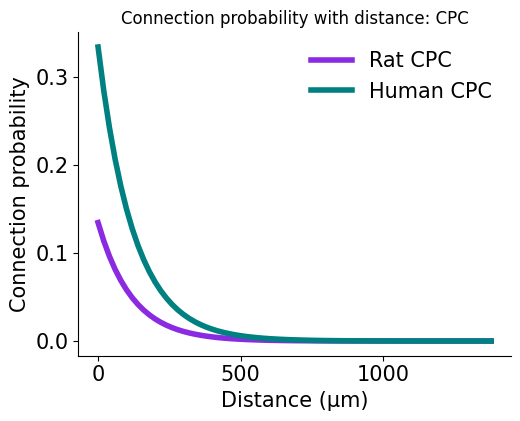

In [13]:
fig = plt.figure(figsize=(5.58, 4.2))
ax0 = plt.subplot()

ax0.plot(x_vector, results["CPC_rat"], color ='blueviolet', linestyle ='solid', linewidth = 4, label='Rat CPC')
ax0.plot(x_vector, results["CPC_human"], color = 'teal', linestyle ='solid', linewidth = 4, label= 'Human CPC')

ax0.tick_params(axis='x', labelsize=15)
ax0.tick_params(axis='y', labelsize=15)
ax0.title.set_text('Connection probability with distance: CPC')
ax0.set_ylabel('Connection probability', fontsize=15)
ax0.set_xlabel('Distance (µm)', fontsize=15)
ax0.spines[['right', 'top']].set_visible(False)
ax0.legend(fontsize=15, frameon=False)

# Figure S3 Number of edges and possible edges as a function of distance 
#### Number of edges per distance bin for all connectivity matrices of human (top), the HC RD model (middle) and rat (bottom).

In [14]:
# transform target columns in dictionaries
def safe_eval(x):
    return eval(x, {"array": np.array, "np": np})

for cn in circuit_name_list:
    # Apply it to the column
    data[cn][0] = safe_eval(data[cn][0])

/var/folders/m2/htrpcvy14219djpfvy9rbhqw0000gn/T/ipykernel_98369/4134836065.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data[cn][0] = safe_eval(data[cn][0])


In [15]:
# Create dictionary with lists to be used in plots
plot_counts = {}

plot_counts['dist_bins_human'] = data['ATC_human'][0]['dist_bins'] # same for all human and control matrices
plot_counts['count_all_human'] = data['ATC_human'][0]['count_all'] # same for all human and control matrices
plot_counts['dist_bins_rat'] = data['ATC_rat'][0]['dist_bins'] # same for all rat matrices
plot_counts['count_all_rat'] = data['ATC_rat'][0]['count_all'] # same for all rat matrices

for cn in circuit_name_list:
    plot_counts[cn] = data[cn][0]['count_conn']

#### Human ATC, human CPC vs control

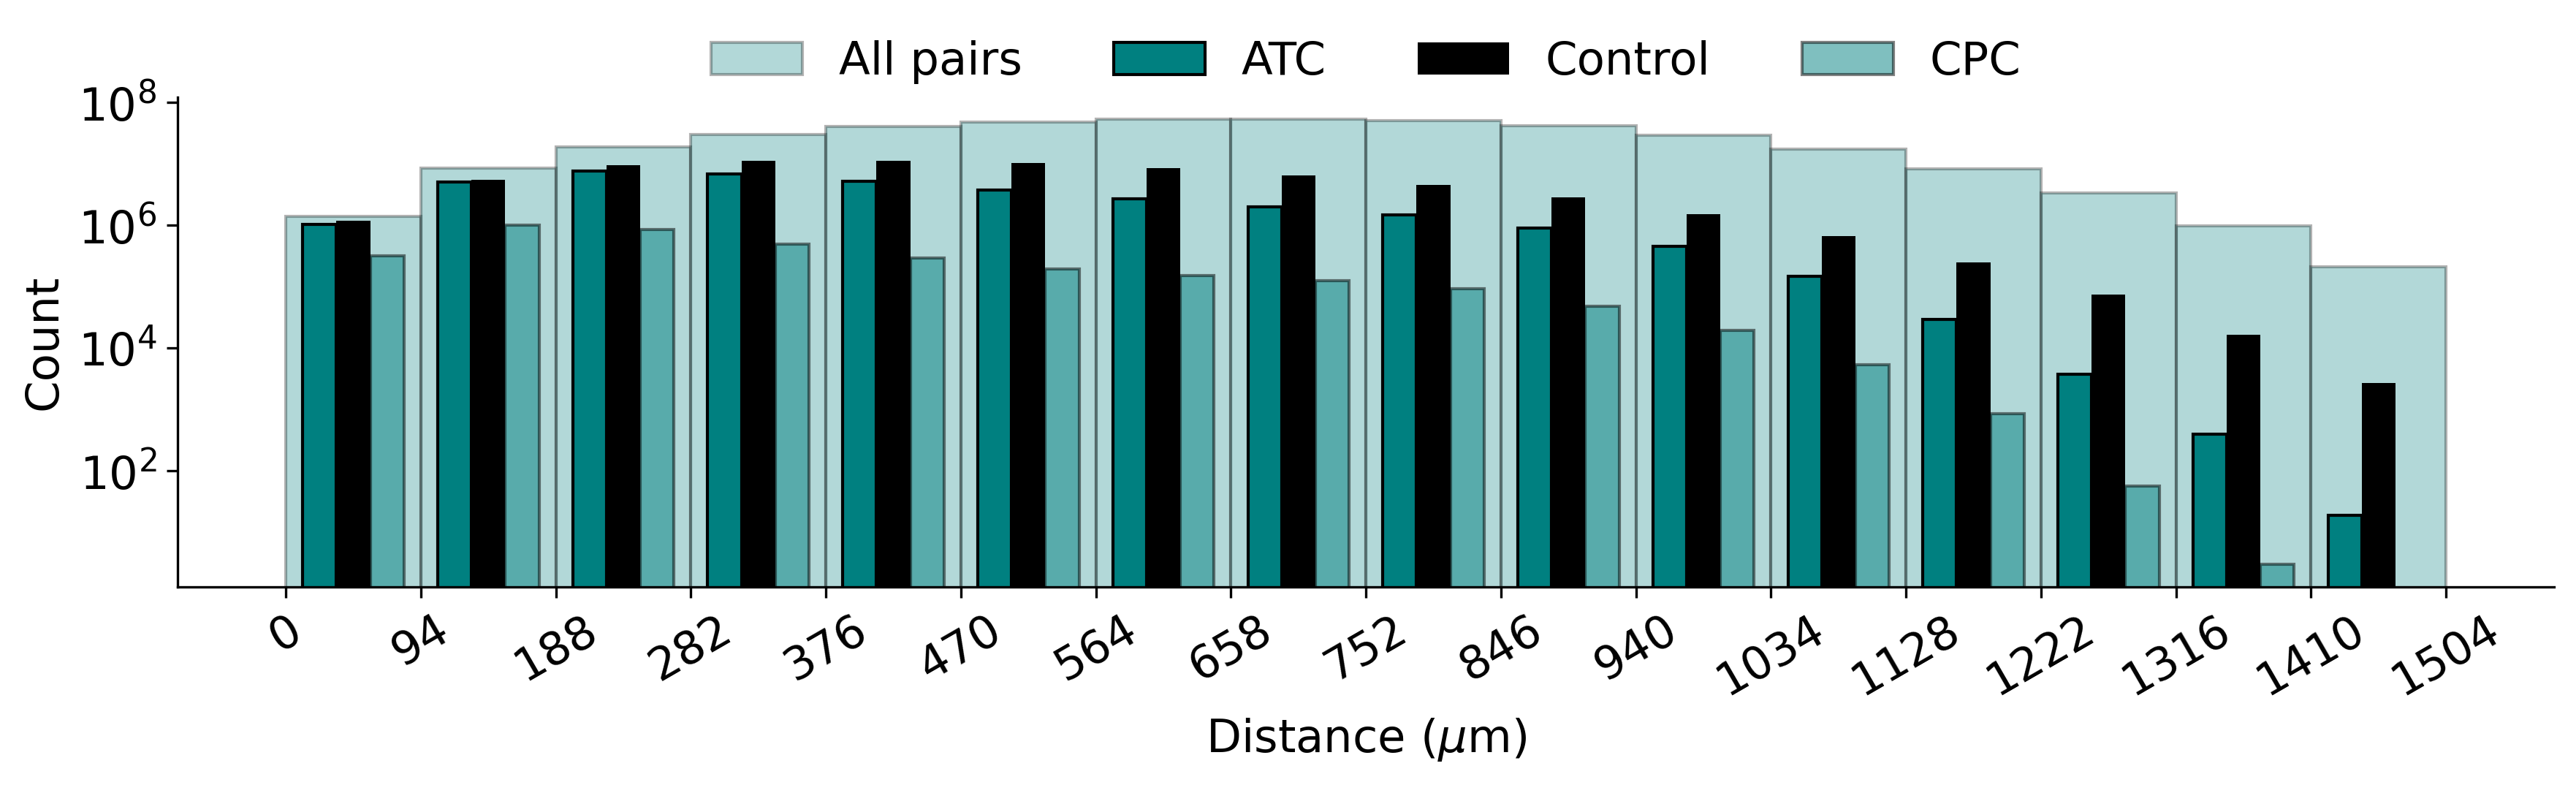

In [17]:
# Data counts
dist_bins = data['ATC_human'][0]['dist_bins']
bin_offset = 0.5 * np.diff(dist_bins[:2])[0]

plt.rcParams.update({'font.size': 15})
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

plt.figure(figsize=(12, 4), dpi=300)

plt.bar(dist_bins[:-1] + bin_offset, plot_counts['count_all_human'], width=2.0 * bin_offset, alpha=0.3, color = 'teal', edgecolor='k', label='All pairs')
plt.bar(dist_bins[:-1] + bin_offset - bin_offset/2, plot_counts['ATC_human'], width=0.5 * bin_offset, color = 'teal', edgecolor='k',  label='ATC')
plt.bar(dist_bins[:-1] + bin_offset, plot_counts['HC_RD'], width=0.5 * bin_offset, color = 'black', label='Control')
plt.bar(dist_bins[:-1] + bin_offset + bin_offset/2, plot_counts['CPC_human'], width=0.5 * bin_offset, alpha=0.5, color = 'teal', edgecolor='k', label='CPC')

plt.gca().set_yscale('log')
plt.xticks(dist_bins, rotation=30)
#plt.yticks(c, fontsize=15)
#plt.grid()
plt.xlabel('Distance ($\\mu$m)')
plt.ylabel('Count')
#plt.title(f'Distance-dependent connection counts. Human structural vs human control based on rat data')
plt.legend(loc='upper center',bbox_to_anchor=(0.5, 1.2),ncol=4, frameon=False)
plt.tight_layout()

#### Human CPC vs all prunings

/var/folders/m2/htrpcvy14219djpfvy9rbhqw0000gn/T/ipykernel_98369/951114621.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


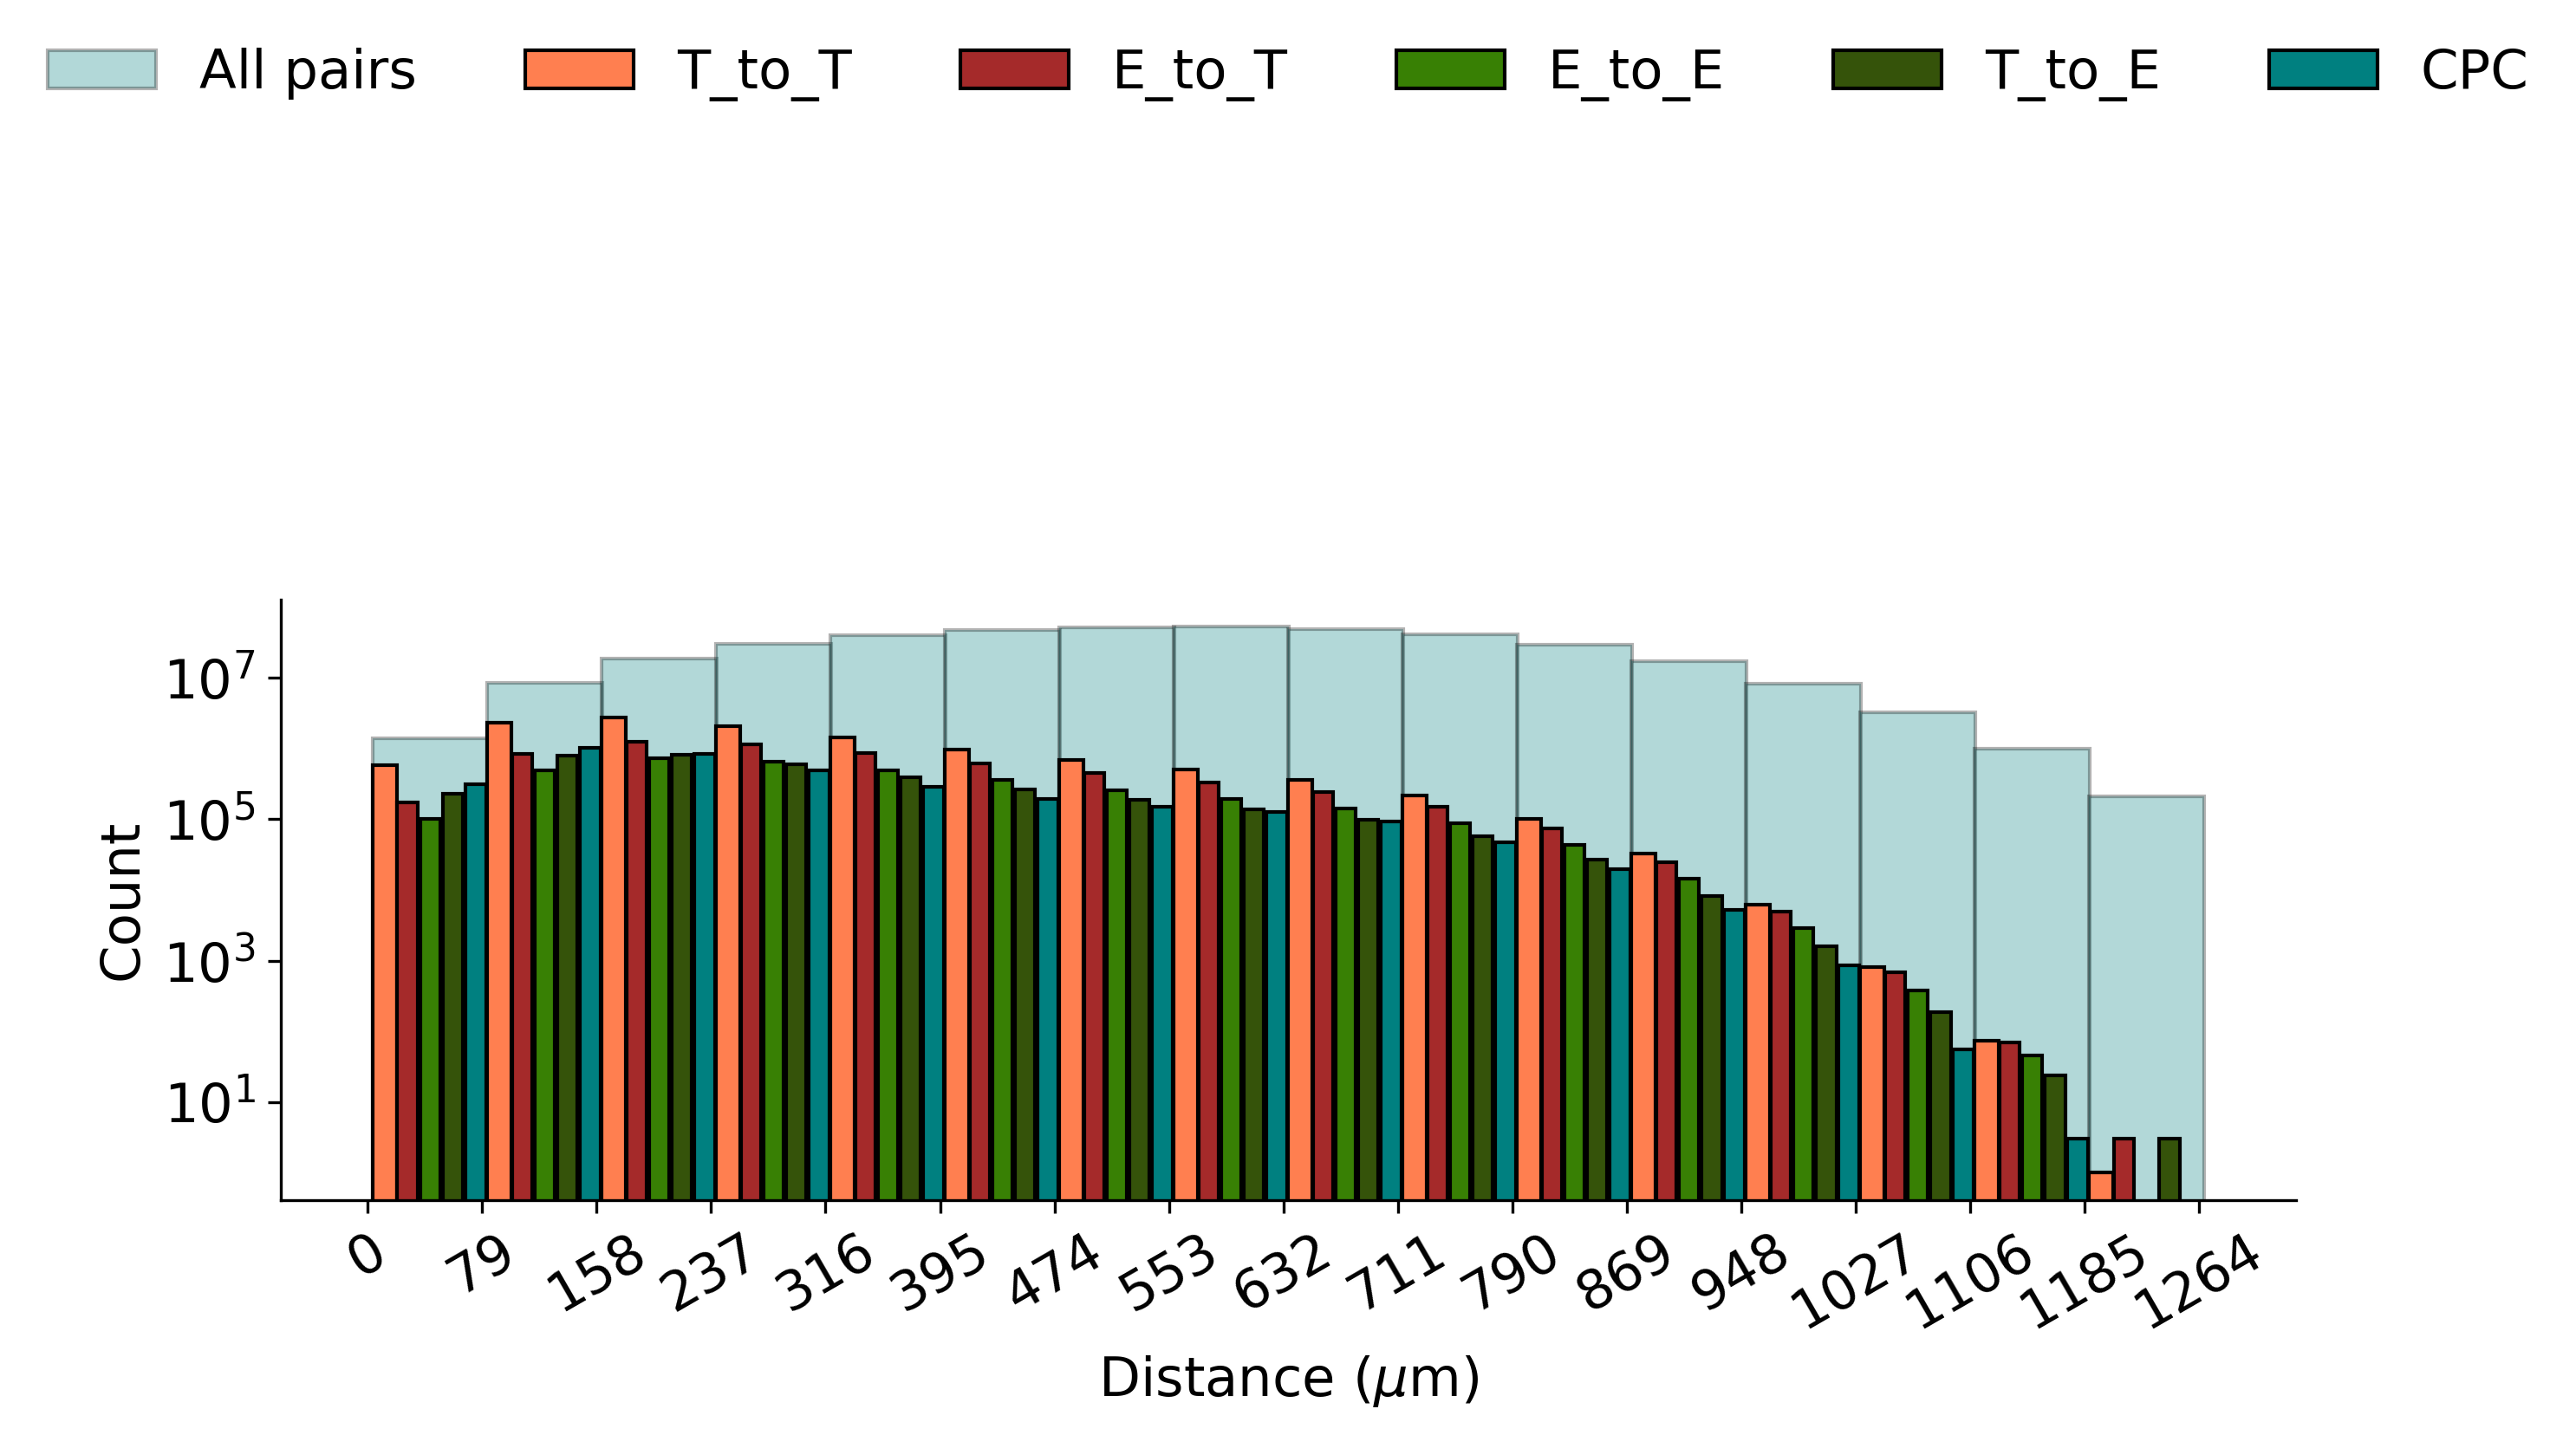

In [35]:
plt.rcParams.update({'font.size': 15})
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

plt.figure(figsize=(10, 3), dpi=300)

plt.bar(dist_bins[:-1] + bin_offset-4., plot_counts['count_all_human'], width=1.7 * bin_offset, alpha=0.3, color = 'teal', edgecolor='k', label='All pairs')
plt.bar(dist_bins[:-1] + bin_offset/4, plot_counts['T_to_T_human'], width=0.35 * bin_offset, color = 'coral', edgecolor='k', label='T_to_T')
plt.bar(dist_bins[:-1] + bin_offset/4 + bin_offset/3, plot_counts['E_to_T_human'], width=0.3 * bin_offset, color = 'brown', edgecolor='k', label='E_to_T')
plt.bar(dist_bins[:-1] + bin_offset/4 + 2*bin_offset/3, plot_counts['E_to_E_human'], width=0.3 * bin_offset, color = '#388004', edgecolor='k', label='E_to_E')
plt.bar(dist_bins[:-1] + bin_offset/4 + 3*bin_offset/3, plot_counts['T_to_E_human'], width=0.3 * bin_offset, color = '#35530a', edgecolor='k', label='T_to_E')
plt.bar(dist_bins[:-1] + bin_offset/4 + 4*bin_offset/3, plot_counts['CPC_human'], width=0.3 * bin_offset, color = 'teal', edgecolor='k',  label='CPC')


plt.gca().set_yscale('log')
plt.xticks(dist_bins, rotation=30)
#plt.yticks(c, fontsize=15)
#plt.grid()
plt.xlabel('Distance ($\\mu$m)')
plt.ylabel('Count')
#plt.title(f'Distance-dependent connection counts. Human ATC vs human control based on rat data')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 2.), ncol=6, frameon=False)
plt.tight_layout()

#### Control vs all control prunings and human CPC

/var/folders/m2/htrpcvy14219djpfvy9rbhqw0000gn/T/ipykernel_98369/310187858.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


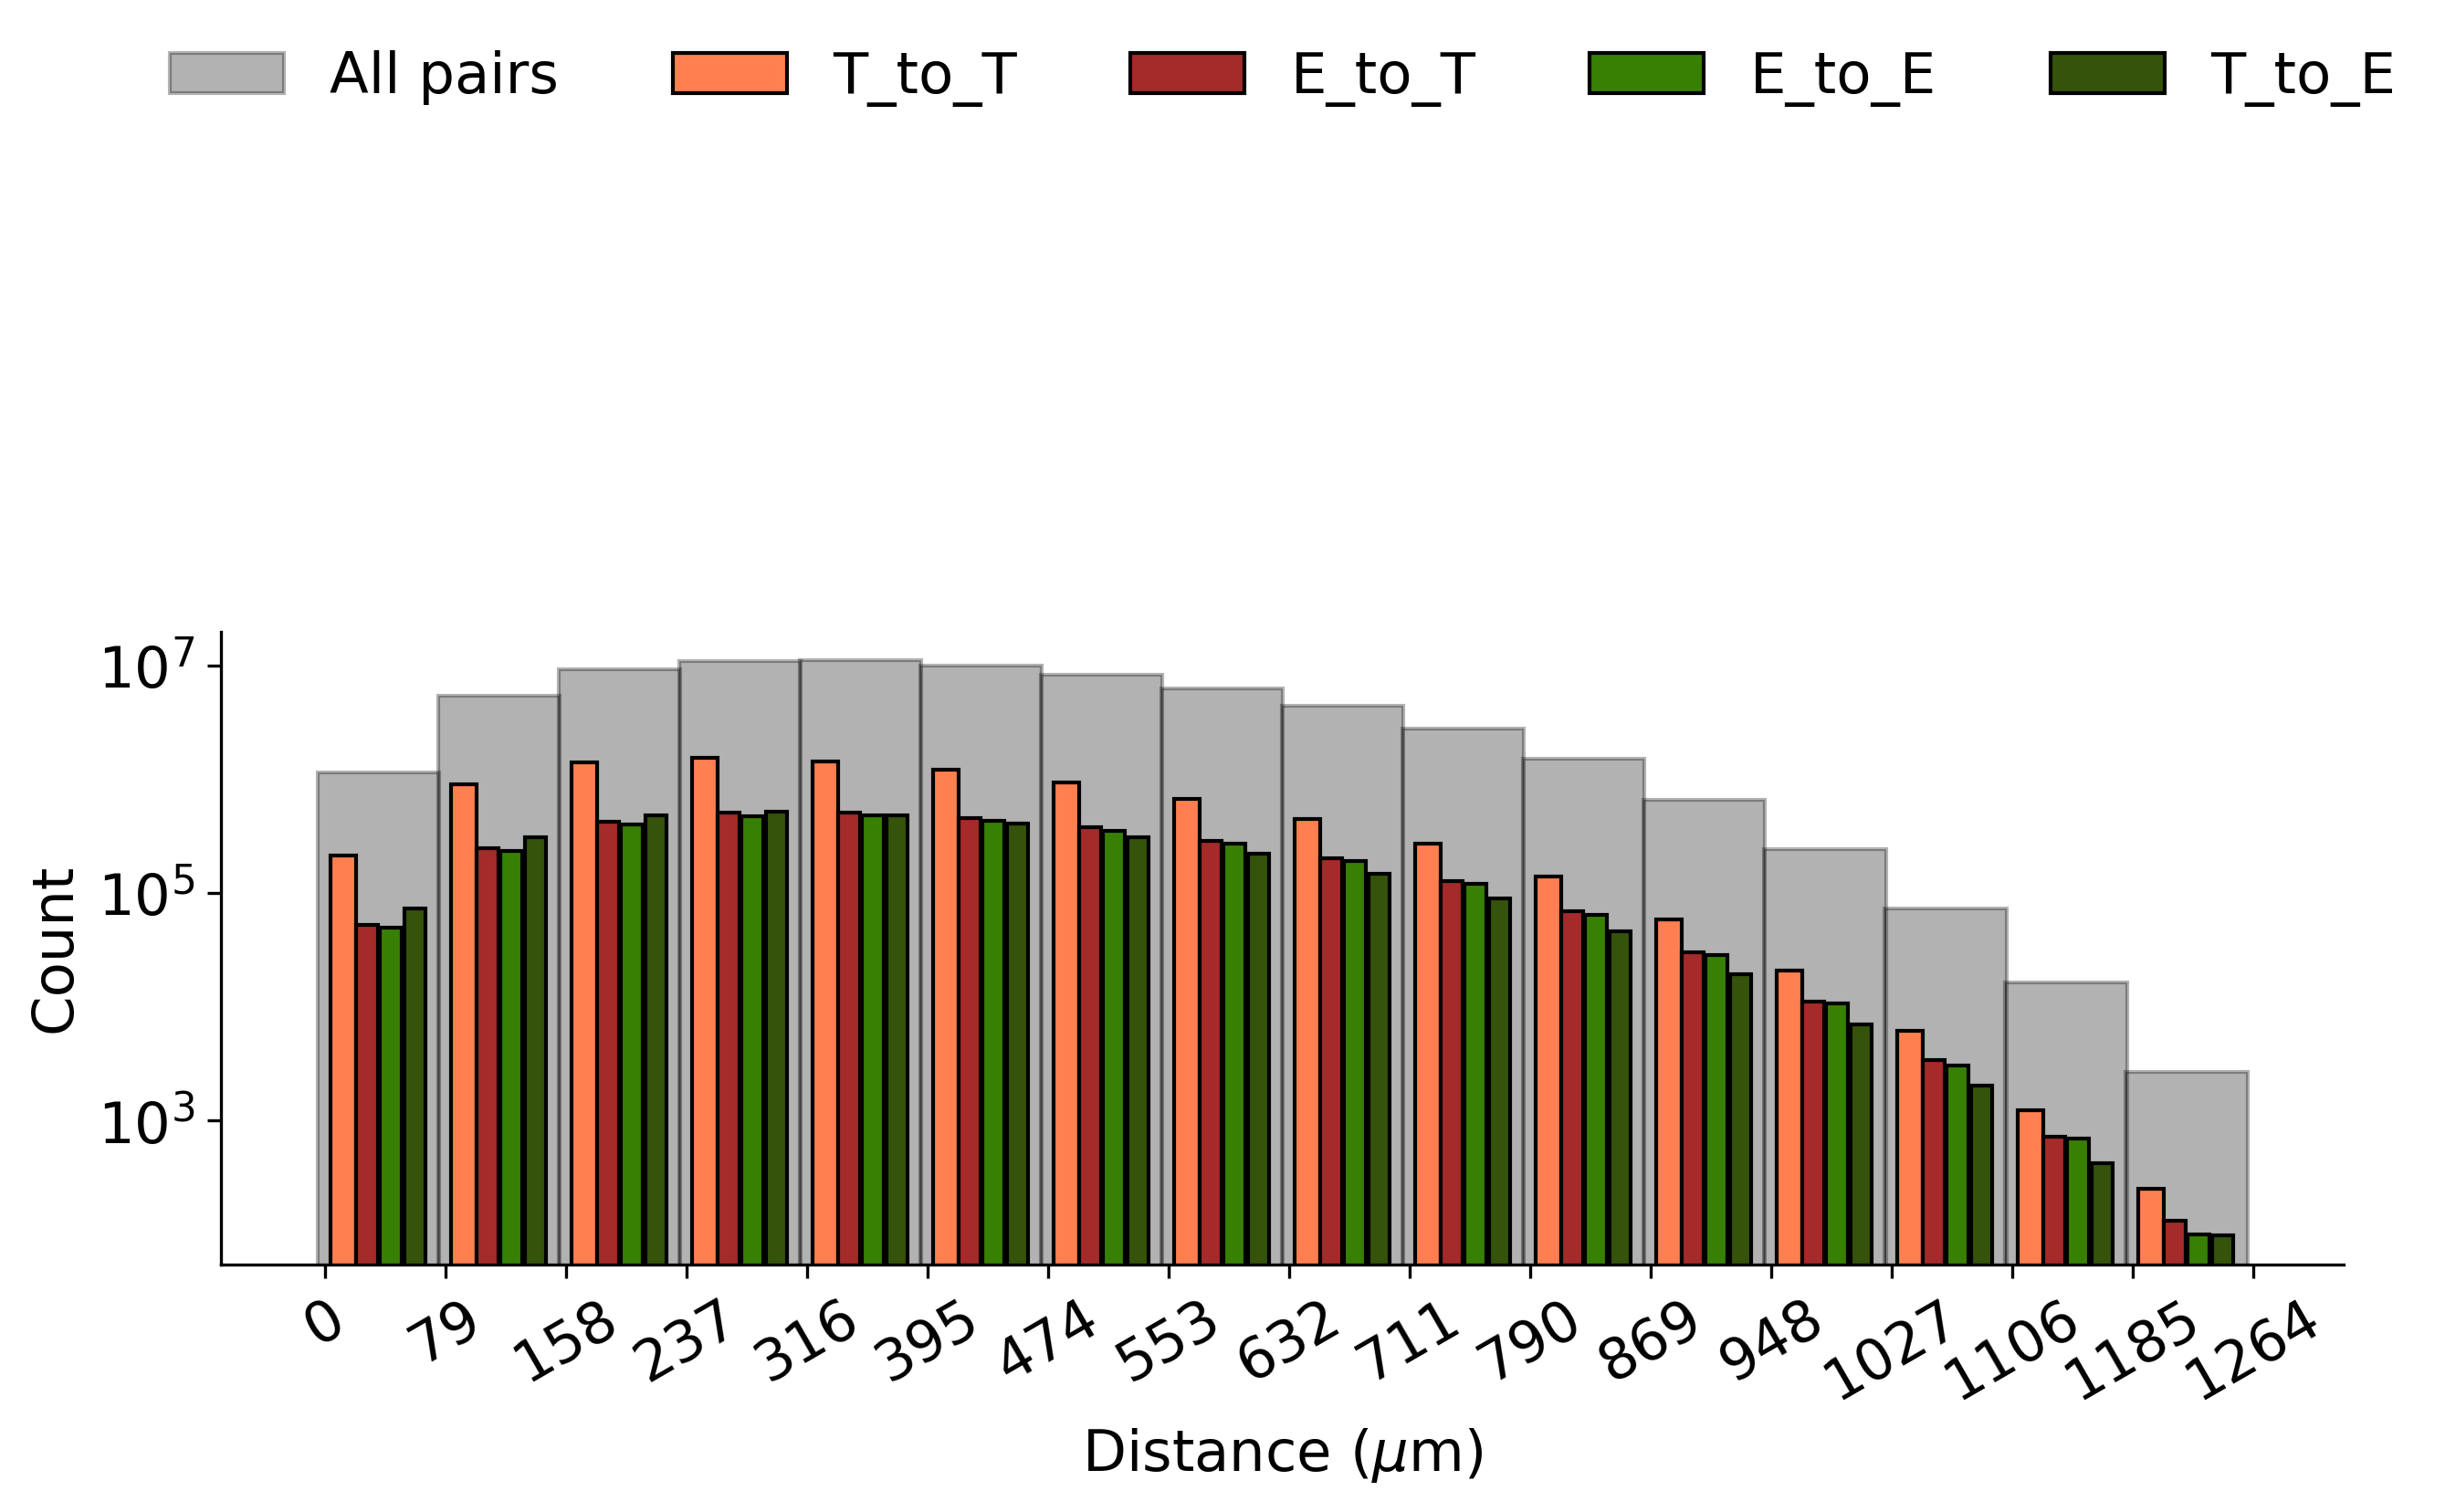

In [37]:
# Control
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

plt.figure(figsize=(10, 3), dpi=300)

plt.bar(dist_bins[:-1] + bin_offset-12., plot_counts['HC_RD'], width=1.7 * bin_offset, alpha=0.3, color = 'black', edgecolor='k', label='All pairs')
plt.bar(dist_bins[:-1] + bin_offset/4, plot_counts['T_to_T_HC_RD'], width=0.35 * bin_offset, color = 'coral', edgecolor='k', label='T_to_T')
plt.bar(dist_bins[:-1] + bin_offset/4 + bin_offset/3, plot_counts['E_to_T_HC_RD'], width=0.3 * bin_offset, color = 'brown', edgecolor='k', label='E_to_T')
plt.bar(dist_bins[:-1] + bin_offset/4 + 2*bin_offset/3, plot_counts['E_to_E_HC_RD'], width=0.3 * bin_offset, color = '#388004', edgecolor='k', label='E_to_E')
plt.bar(dist_bins[:-1] + bin_offset/4 + 3*bin_offset/3, plot_counts['T_to_E_HC_RD'], width=0.3 * bin_offset, color = '#35530a', edgecolor='k', label='T_to_E')


plt.gca().set_yscale('log')
plt.xticks(dist_bins, rotation=30)
#plt.yticks(c, fontsize=15)
#plt.grid()
plt.xlabel('Distance ($\\mu$m)')
plt.ylabel('Count')
#plt.title(f'Distance-dependent connection counts. Human structural vs human control based on rat data')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 2.), ncol=6, frameon=False)
plt.tight_layout()

#### Rat ATC vs all rat prunings 

/var/folders/m2/htrpcvy14219djpfvy9rbhqw0000gn/T/ipykernel_98369/1100619957.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


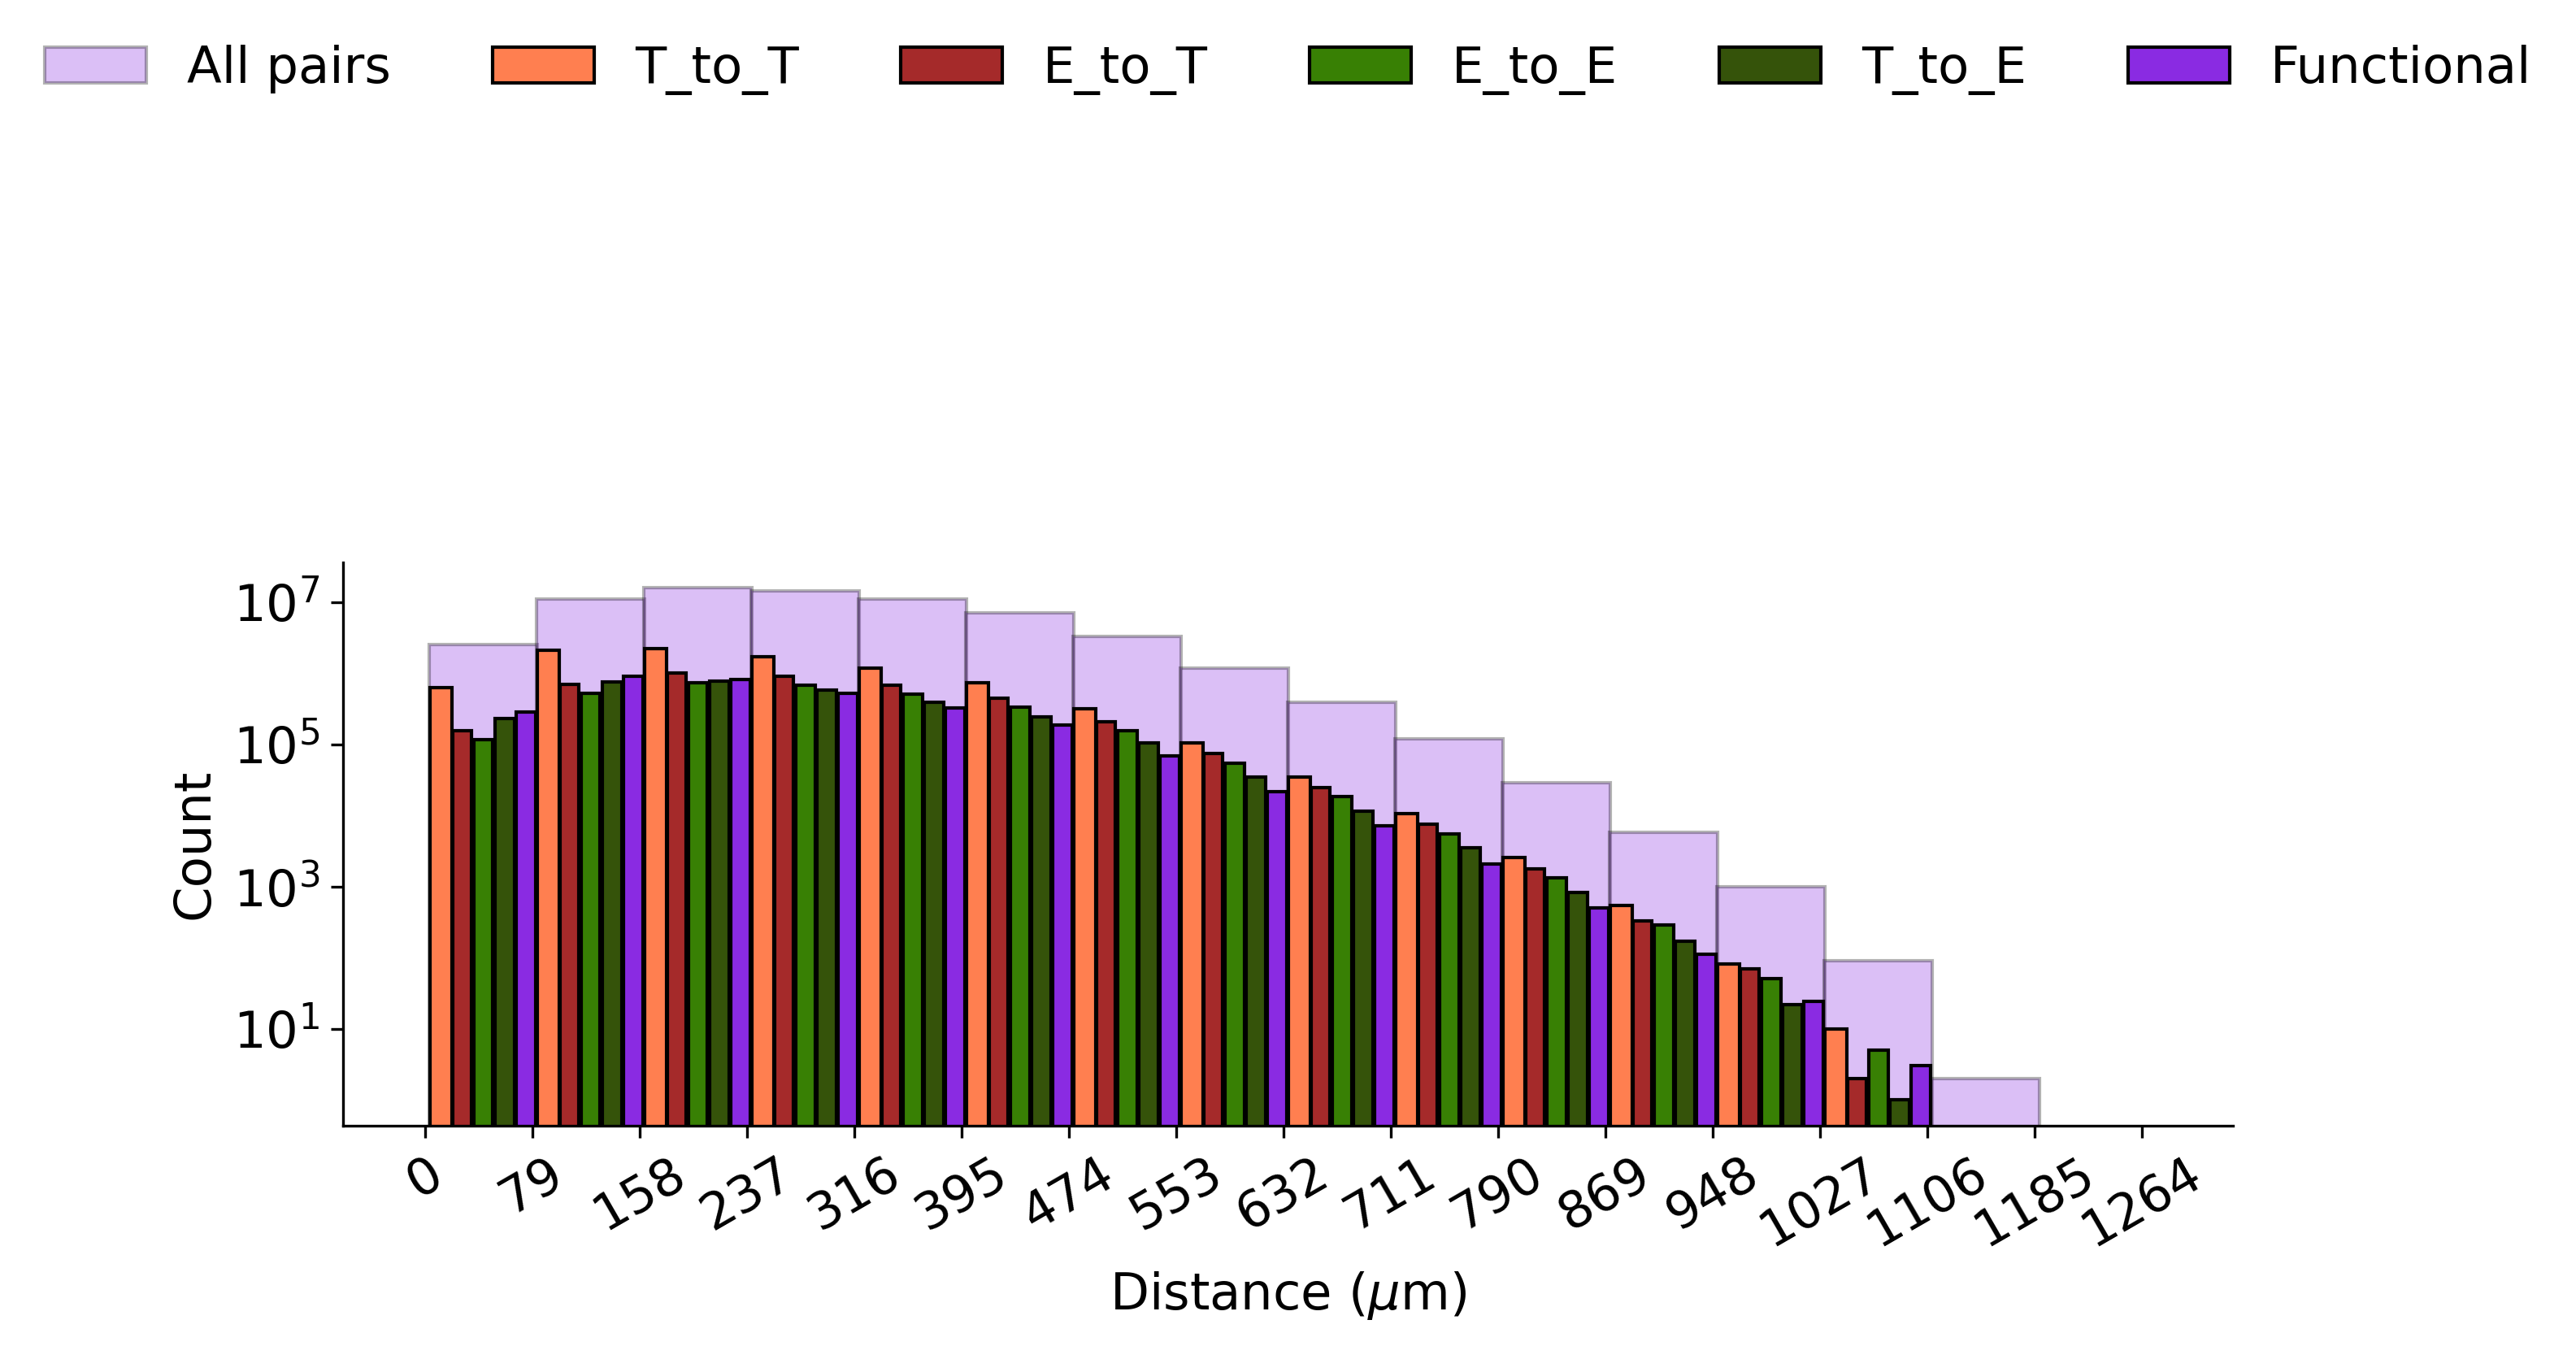

In [38]:
# Rat
dist_bins = data['ATC_rat'][0]['dist_bins']
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

plt.figure(figsize=(10, 3), dpi=300)

plt.bar(dist_bins[:-1] + bin_offset-4., plot_counts['ATC_rat'], width=1.7 * bin_offset, alpha=0.3, color = 'blueviolet', edgecolor='k', label='All pairs')
plt.bar(dist_bins[:-1] + bin_offset/4, plot_counts['T_to_T_rat'], width=0.35 * bin_offset, color = 'coral', edgecolor='k', label='T_to_T')
plt.bar(dist_bins[:-1] + bin_offset/4 + bin_offset/3, plot_counts['E_to_T_rat'], width=0.3 * bin_offset, color = 'brown', edgecolor='k', label='E_to_T')
plt.bar(dist_bins[:-1] + bin_offset/4 + 2*bin_offset/3, plot_counts['E_to_E_rat'], width=0.3 * bin_offset, color = '#388004', edgecolor='k', label='E_to_E')
plt.bar(dist_bins[:-1] + bin_offset/4 + 3*bin_offset/3, plot_counts['T_to_E_rat'], width=0.3 * bin_offset, color = '#35530a', edgecolor='k', label='T_to_E')
plt.bar(dist_bins[:-1] + bin_offset/4 + 4*bin_offset/3, plot_counts['CPC_rat'], width=0.3 * bin_offset, color = 'blueviolet', edgecolor='k',  label='Functional')


plt.gca().set_yscale('log')
plt.xticks(dist_bins, rotation=30)
#plt.yticks(c, fontsize=15)
#plt.grid()
plt.xlabel('Distance ($\\mu$m)')
plt.ylabel('Count')
#plt.title(f'Distance-dependent connection counts. Human structural vs human control based on rat data')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 2.), ncol=6, frameon=False)
plt.tight_layout()